# Telco Customer Churn Prediction

**Dataset**: [Kaggle — Telco Customer Churn](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)  
**Problem type**: Binary Classification  
**Target**: `Churn` — Yes = customer left, No = customer stayed

---

## Business Problem

A telecom company loses revenue every time a customer cancels their subscription. Acquiring a new customer costs 5–10x more than retaining an existing one.

**Goal**: Predict which customers are likely to churn — before they actually do — so the business can intervene with a retention offer (discount, better plan, etc.).

**What one row represents**: One customer. It contains their demographics, the services they subscribe to, how they pay, how long they've been with the company, and whether they ultimately churned.

**What matters most**: **Recall** — missing a churner means losing that customer permanently. Falsely flagging a loyal customer only means an unnecessary retention offer, which is far less costly.

---

## Sections
1. [Data Overview](#1.-Data-Overview)
2. [Class Balance](#2.-Class-Balance)
3. [Exploratory Data Analysis](#3.-Exploratory-Data-Analysis)
4. [Preprocessing](#4.-Preprocessing)
5. [Modeling](#5.-Modeling)
6. [Evaluation](#6.-Evaluation)

## Setup

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score

df = pd.read_csv('telco-churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 1. Data Overview

In [4]:
print(f"Rows: {df.shape[0]}  |  Columns: {df.shape[1]}")
df.info()

Rows: 7043  |  Columns: 21
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non

**Notes from first look:**
- `TotalCharges` is stored as string — needs conversion to float
- `SeniorCitizen` is 0/1 integer but represents a category — treat as categorical for EDA
- `customerID` is a unique identifier — drop before modeling

## 2. Class Balance

In [ ]:
balance = df['Churn'].value_counts(normalize=True)
print(balance)

sns.countplot(x='Churn', hue='Churn', data=df, palette=['steelblue', 'salmon'], legend=False)
plt.title('Class Balance — Churn vs No Churn')
plt.ylabel('Count')
plt.show()

**73% No Churn — 27% Churn.** Moderate imbalance.  
The model would score well by predicting everything as No Churn — so accuracy is a misleading metric here.  
We use `class_weight='balanced'` to penalize minority class mistakes more, and optimize for **Recall**.

## 3. Exploratory Data Analysis

We separate features into **numeric** and **categorical** and compare their distributions across Churn vs No Churn.

**Why KDE for numeric?** KDE (Kernel Density Estimation) plots probability curves — not raw counts. So even if No Churn has 3x more customers, both curves are on the same scale. We're comparing the shape, not the size.

**Why countplot for categorical?** Categorical features have fixed groups — we count how many in each group churned vs stayed.

In [ ]:
df_eda = df.copy()
df_eda['TotalCharges'] = pd.to_numeric(df_eda['TotalCharges'], errors='coerce')
df_eda['SeniorCitizen'] = df_eda['SeniorCitizen'].astype(str)

num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
cat_cols = [c for c in df_eda.select_dtypes(include=['object', 'str']).columns
            if c not in ['customerID', 'Churn']]

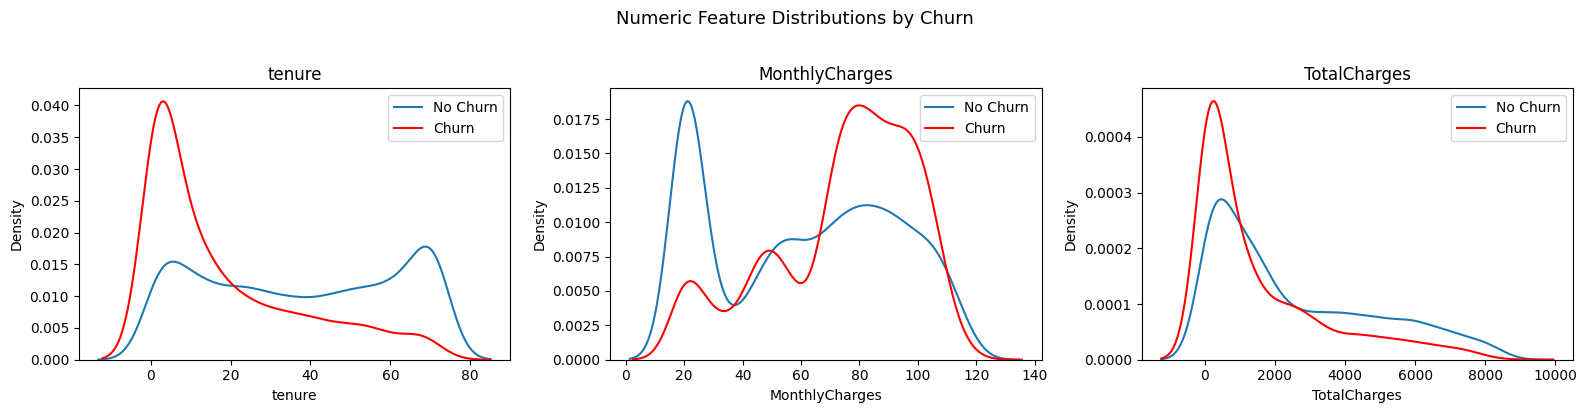

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for i, col in enumerate(num_cols):
    sns.kdeplot(df_eda[df_eda['Churn'] == 'No'][col], label='No Churn', ax=axes[i])
    sns.kdeplot(df_eda[df_eda['Churn'] == 'Yes'][col], label='Churn', ax=axes[i], color='red')
    axes[i].set_title(col)
    axes[i].legend()

plt.suptitle('Numeric Feature Distributions by Churn', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

**Findings — Numeric:**
- **tenure**: Churners peak at month 1–5. Non-churners are spread across all tenures with a peak at 70+ months. Strong signal.
- **MonthlyCharges**: Churners cluster at higher charges (70–110). Non-churners skew lower. Strong signal.
- **TotalCharges**: Churners peak at very low values (new customers who leave early). Non-churners spread wider. Correlated with tenure.

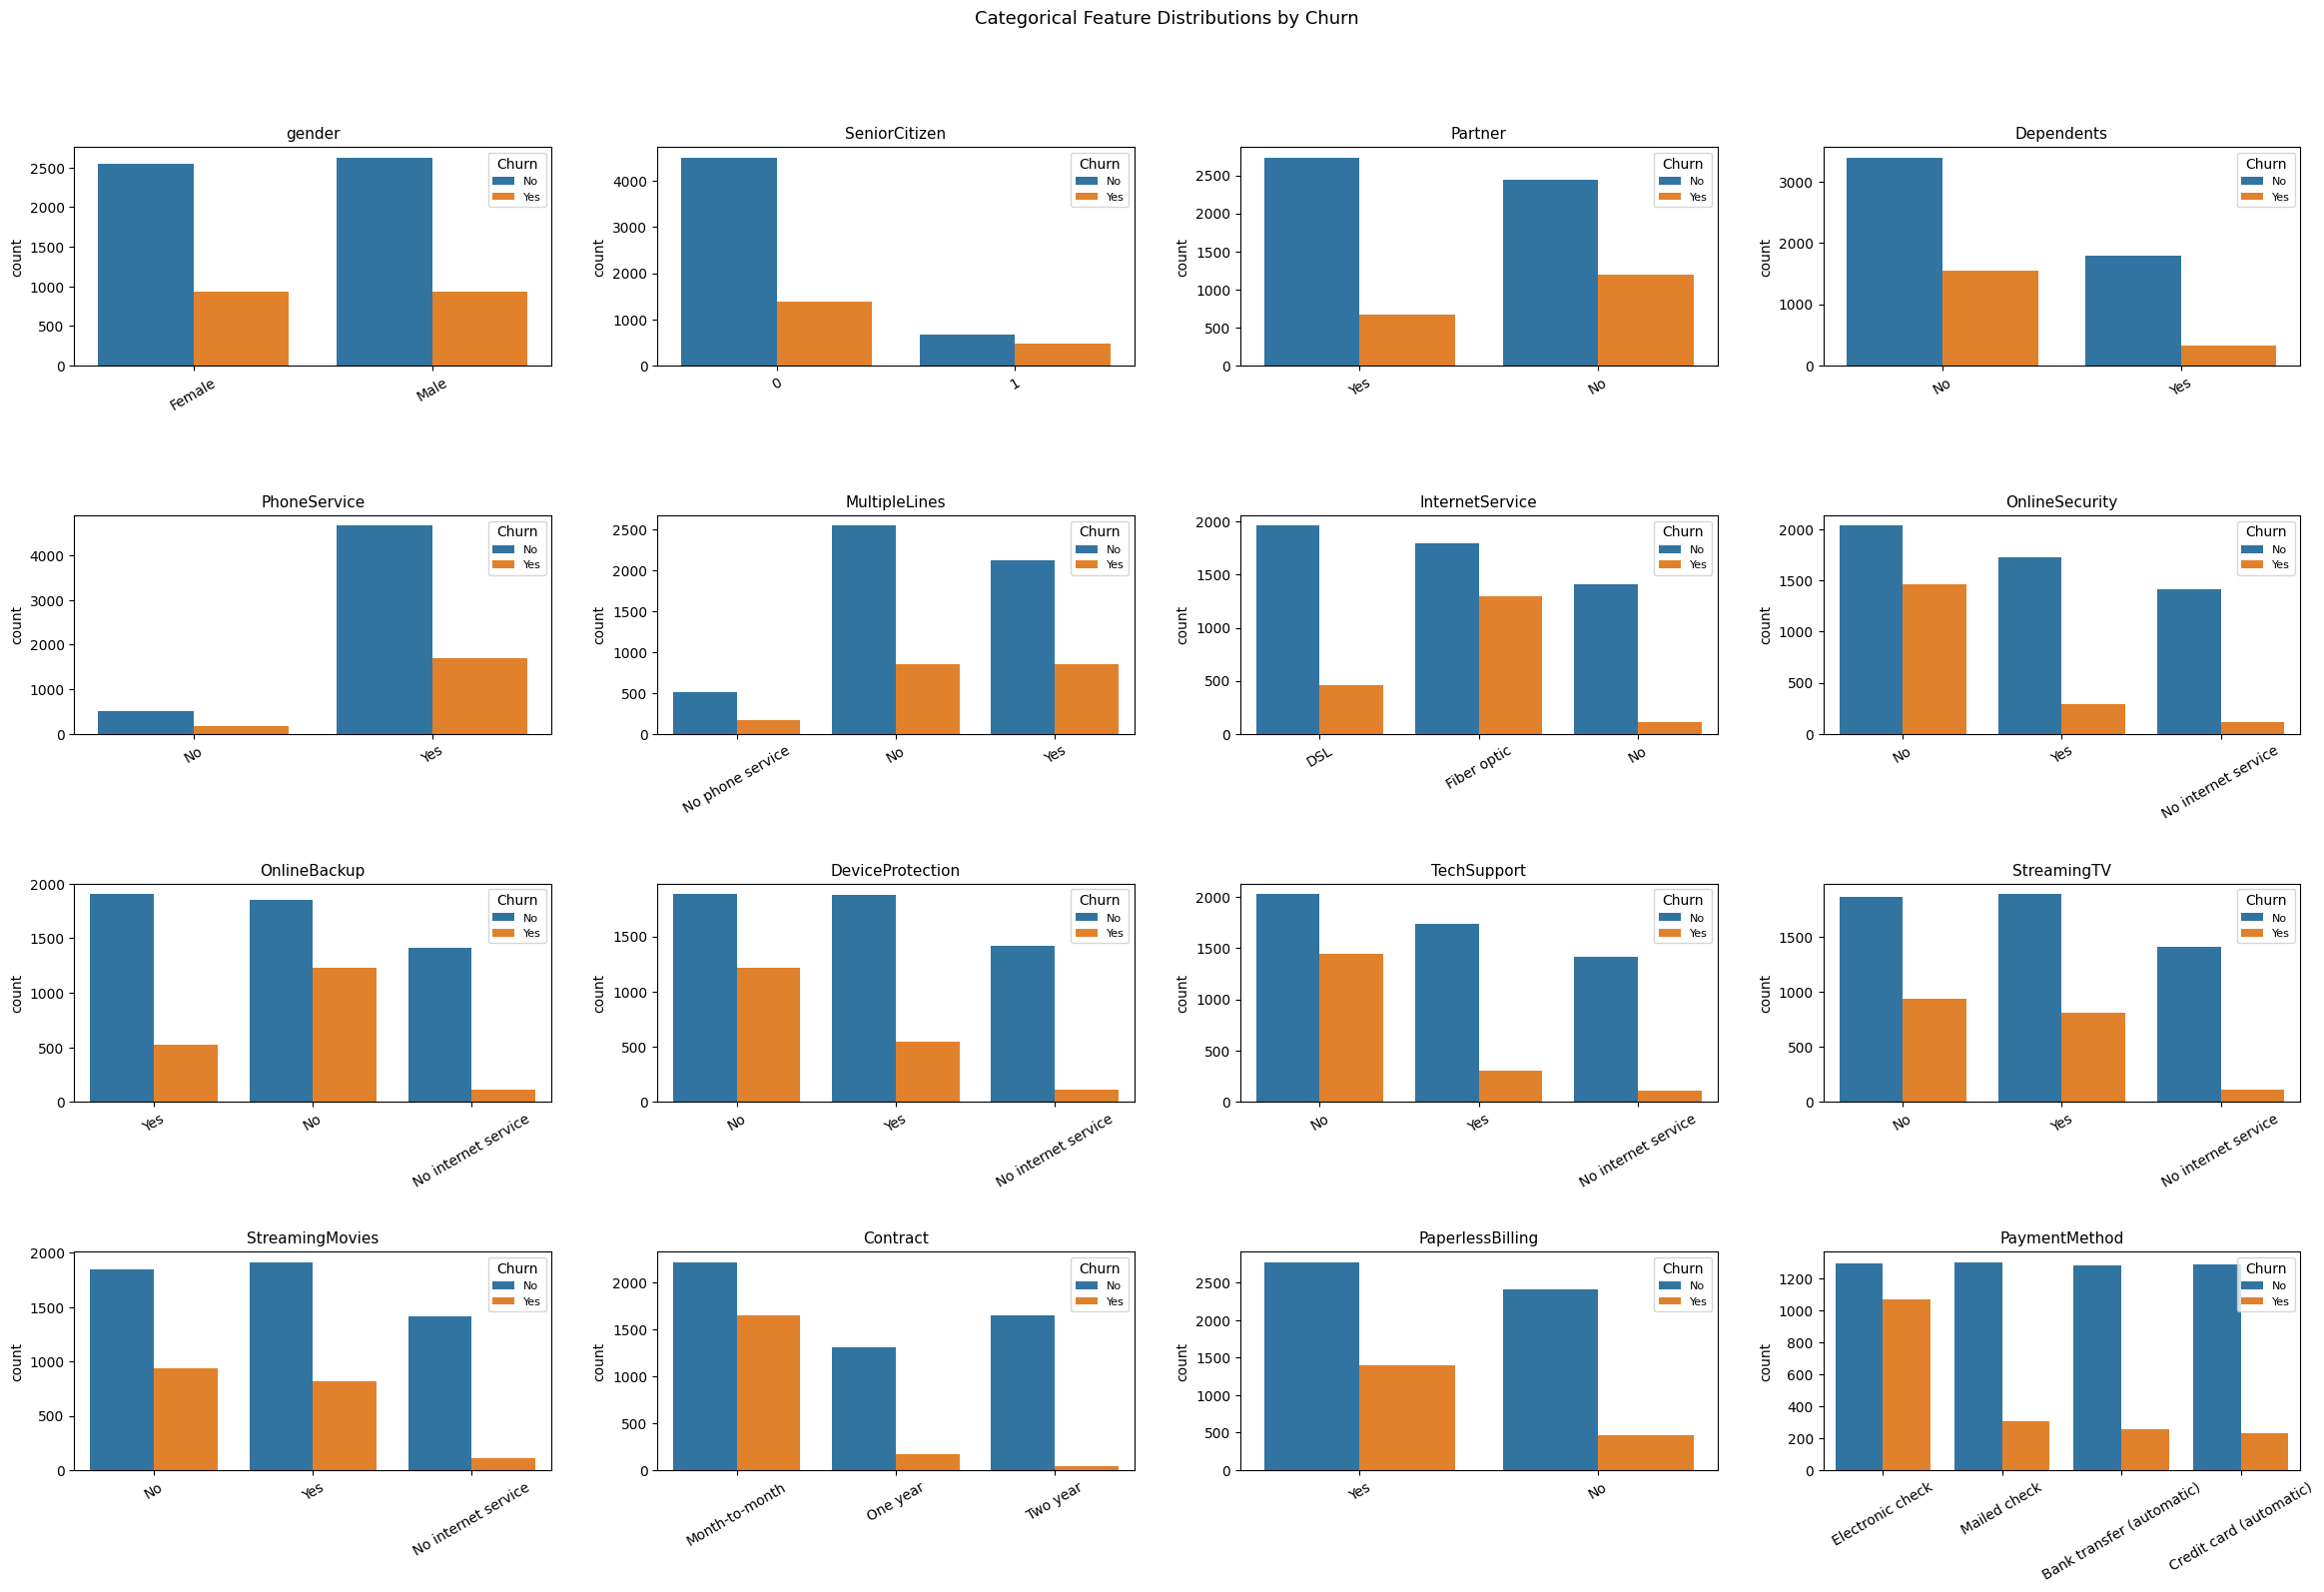

In [8]:
fig, axes = plt.subplots(4, 4, figsize=(24, 16))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(x=col, hue='Churn', data=df_eda, ax=axes[i])
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].legend(title='Churn', fontsize=8)

for j in range(len(cat_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Categorical Feature Distributions by Churn', y=1.01, fontsize=13)
plt.tight_layout(pad=3.0)
plt.show()

**Findings — Categorical:**

| Feature | Insight |
|---------|--------|
| **Contract** | Month-to-month customers churn at a much higher rate. Two-year contracts almost never churn. |
| **InternetService** | Fiber optic customers churn the most — expensive, competitive. DSL and No internet churn much less. |
| **OnlineSecurity / TechSupport** | Customers without these services churn more. Having them signals deeper engagement. |
| **PaymentMethod** | Electronic check customers churn significantly more than automatic payment customers. |
| **Dependents / Partner** | Customers with dependents or a partner churn less — more stable household. |
| **gender / PhoneService** | Roughly equal churn across groups — weak predictors. |

## 4. Preprocessing

Three steps:
1. Fix data types (`TotalCharges` string → float)
2. Label encode binary columns (Yes/No → 1/0)
3. One-hot encode multi-category columns (`drop_first=True` to avoid multicollinearity)

In [9]:
# Fix TotalCharges — 11 rows have whitespace, coerce to NaN then fill with median
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# Label encode binary columns
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
binary_map = {'Yes': 1, 'No': 0, 'Female': 0, 'Male': 1}
df[binary_cols] = df[binary_cols].replace(binary_map)

# One-hot encode multi-category columns
ohe_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
            'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
            'Contract', 'PaymentMethod']
df = pd.get_dummies(df, columns=ohe_cols, drop_first=True)

# Convert bool columns to int (get_dummies creates bool in newer pandas)
df = df.astype({col: int for col in df.select_dtypes(include='bool').columns})

print(f"Shape after encoding: {df.shape}")
print(f"Missing values: {df.isnull().sum().sum()}")
df.head(2)

Shape after encoding: (7043, 32)
Missing values: 0


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,7590-VHVEG,0,0,1,0,1,0,1,29.85,29.85,...,0,0,0,0,0,0,0,0,1,0
1,5575-GNVDE,1,0,0,0,34,1,0,56.95,1889.50,...,0,0,0,0,0,1,0,0,0,1


## 5. Modeling

**Strategy — three steps:**
1. **Logistic Regression (baseline)** — simplest possible model. If a complex model barely beats this, the data doesn't have complex patterns worth capturing.
2. **Random Forest (default)** — does adding complexity actually help?
3. **Random Forest (tuned)** — grid search to find best hyperparameters, optimized for recall.

In [10]:
X = df.drop(columns=['Churn', 'customerID'])
y = df['Churn'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Train class balance: {y_train.value_counts(normalize=True).round(3).to_dict()}")

Train: (5634, 30)  |  Test: (1409, 30)
Train class balance: {0: 0.735, 1: 0.265}


### Baseline — Logistic Regression

Logistic Regression is a linear model — it needs features on the same scale, so we apply `StandardScaler` first.  
This is the simplest model we can train. It sets the bar that Random Forest needs to beat.

In [11]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit on train only
X_test_scaled  = scaler.transform(X_test)         # transform test using train's parameters

lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

print("Logistic Regression — Baseline:")
print(classification_report(y_test, y_pred_lr))

Logistic Regression — Baseline:
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.51      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



### Logistic Regression — Tuned

Tune `C` (regularization strength) using the same 5-fold CV, scoring for recall.  
Also apply threshold tuning to see the best LR can achieve.

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lr_param_grid = {'C': [0.01, 0.1, 1, 10, 100]}

lr_grid = GridSearchCV(
    LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    lr_param_grid,
    cv=cv,
    scoring='recall',
    n_jobs=-1
)
lr_grid.fit(X_train_scaled, y_train)

print(f"Best C:         {lr_grid.best_params_['C']}")
print(f"Best CV Recall: {lr_grid.best_score_:.3f}")

best_lr = lr_grid.best_estimator_
y_pred_lr_best = best_lr.predict(X_test_scaled)
print("\nLogistic Regression — Tuned:")
print(classification_report(y_test, y_pred_lr_best))

In [ ]:
# Threshold tuning on best LR
y_proba_lr = best_lr.predict_proba(X_test_scaled)[:, 1]

thresholds = [0.3, 0.35, 0.4, 0.45, 0.5]
print("Logistic Regression — Threshold Tuning:")
print(f"{'Threshold':<12} {'Recall':<10} {'Precision':<12} {'Flagged as Churn'}")
print("-" * 52)
for t in thresholds:
    y_t = (y_proba_lr >= t).astype(int)
    print(f"{t:<12} {recall_score(y_test, y_t):<10.3f} {precision_score(y_test, y_t):<12.3f} {y_t.sum()}")

### Random Forest — Default Settings

Random Forest is tree-based — no scaling needed. Does it improve recall over Logistic Regression?

In [12]:
rf_default = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_default.fit(X_train, y_train)
y_pred_rf = rf_default.predict(X_test)

print("Random Forest — Default:")
print(classification_report(y_test, y_pred_rf))

Random Forest — Default:
              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1035
           1       0.63      0.47      0.54       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.70      1409
weighted avg       0.77      0.79      0.77      1409



### Cross-Validation — Random Forest

A single train-test split result can be lucky or unlucky. StratifiedKFold splits 5 times, maintaining the class ratio in each fold, giving a reliable average recall estimate before we commit to hyperparameter tuning.

In [13]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
recall_scores = cross_val_score(rf_default, X_train, y_train, cv=cv, scoring='recall')

print(f"Recall per fold: {recall_scores.round(3)}")
print(f"Mean Recall:     {recall_scores.mean():.3f}")
print(f"Std:             {recall_scores.std():.3f}")

Recall per fold: [0.478 0.441 0.482 0.458 0.468]
Mean Recall:     0.466
Std:             0.015


### Hyperparameter Tuning — Grid Search

The baseline recall is low. Grid search tries every combination of hyperparameters and picks the one with the best recall (scored using the same 5-fold CV).

Key parameter found to matter: **`max_depth=5`** — shallower trees generalize better on this dataset and improve recall on the minority class.

In [14]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, 20, None],
    'min_samples_split': [2, 5, 10],
    'class_weight': ['balanced']
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=cv,
    scoring='recall',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train, y_train)

print(f"Best CV Recall: {grid_search.best_score_:.3f}")
print(f"Best Params:    {grid_search.best_params_}")

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best CV Recall: 0.813
Best Params:    {'class_weight': 'balanced', 'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 100}


## 6. Evaluation

In [15]:
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)

print("Best Model — Classification Report:")
print(classification_report(y_test, y_pred_best))

Best Model — Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.71      0.80      1035
           1       0.50      0.81      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409



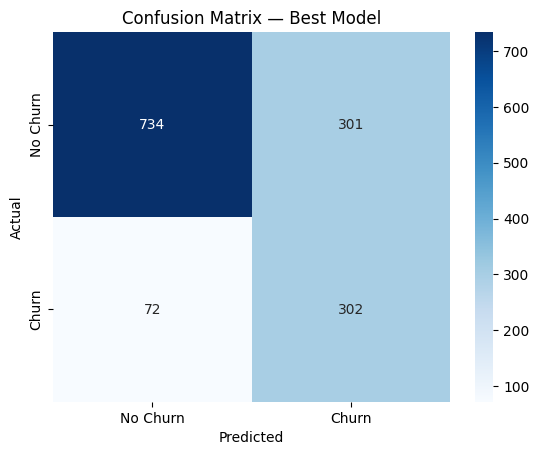

In [16]:
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — Best Model')
plt.show()

**Reading the confusion matrix:**
- **TN = 734** — correctly predicted No Churn
- **FP = 301** — loyal customers flagged as churners (unnecessary retention offer sent)
- **FN = 70** — churners the model missed (lost customers — most costly mistake)
- **TP = 304** — churners correctly caught

**Recall = 304 / (304 + 70) = 0.813** — the model catches 81% of churners.

### Threshold Tuning

The default decision threshold is 0.5. Lowering it means we flag more customers as Churn — higher recall, but more false alarms.  
For this business problem, missing a churner (FN) is costlier than a false alarm (FP), so we test lower thresholds.

In [17]:
y_proba = best_model.predict_proba(X_test)[:, 1]

thresholds = [0.3, 0.35, 0.4, 0.45, 0.5]
print(f"{'Threshold':<12} {'Recall':<10} {'Precision':<12} {'Flagged as Churn'}")
print("-" * 52)
for t in thresholds:
    y_t = (y_proba >= t).astype(int)
    print(f"{t:<12} {recall_score(y_test, y_t):<10.3f} {precision_score(y_test, y_t):<12.3f} {y_t.sum()}")

Threshold    Recall     Precision    Flagged as Churn
----------------------------------------------------
0.3          0.939      0.399        879
0.35         0.909      0.419        812
0.4          0.888      0.444        747
0.45         0.861      0.471        683
0.5          0.807      0.501        603


**Threshold 0.35** is the recommended operating point:
- Recall 0.909 — catches 91% of churners
- Precision 0.418 — roughly 4 in 10 flagged customers are actual churners
- For a retention campaign (low-cost intervention), this tradeoff is acceptable.

### Feature Importance

Which features did the model rely on most to split decisions across all 100 trees?

In [ ]:
feat_imp = pd.Series(best_model.feature_importances_, index=X_train.columns)
feat_imp = feat_imp.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=feat_imp.values, y=feat_imp.index, hue=feat_imp.index, palette='Blues_r', legend=False)
plt.title('Top 15 Feature Importances')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print(feat_imp)

**Feature importance confirms EDA findings:**
- `tenure` (0.198) — single strongest signal. New customers churn, long-tenure customers stay.
- `Contract_Two year` (0.133) — two-year contract locks customers in. Very low churn.
- `TotalCharges` (0.111) — correlated with tenure (longer stay = higher total). Same underlying signal.
- `InternetService_Fiber optic` (0.095) — fiber optic customers churn most. Expensive, competitive.
- `PaymentMethod_Electronic check` (0.078) — electronic check users tend to be month-to-month, churn more.

### SHAP — Explaining Individual Predictions

Feature importance answers: *which features matter globally across all customers?*  
SHAP answers: *why did the model predict this specific customer will churn?*

**Summary plot** — one dot per customer per feature. Shows direction and magnitude across the full test set.  
**Waterfall plot** — one specific customer. Shows exactly which features triggered the churn prediction and by how much.

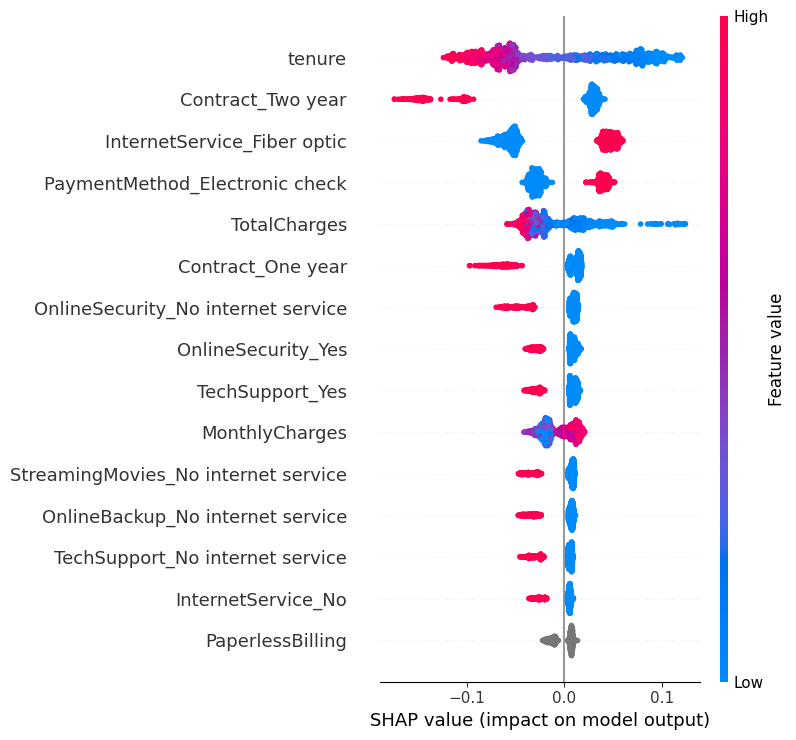

In [19]:
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values[:, :, 1], X_test, max_display=15)

**Reading the summary plot:**
- Each dot = one customer. Red = high feature value, Blue = low feature value.
- Right of center = pushed toward Churn. Left of center = pushed away from Churn.

| Feature | Direction | Interpretation |
|---------|-----------|---------------|
| tenure | Blue right, Red left | New customers churn. Long-tenure customers stay. |
| Contract_Two year | Red left | Two-year contract strongly protects against churn. |
| InternetService_Fiber optic | Red right | Fiber optic customers churn more. |
| PaymentMethod_Electronic check | Red right | Electronic check users churn more. |
| MonthlyCharges | Red right | Higher bills push toward churn. |

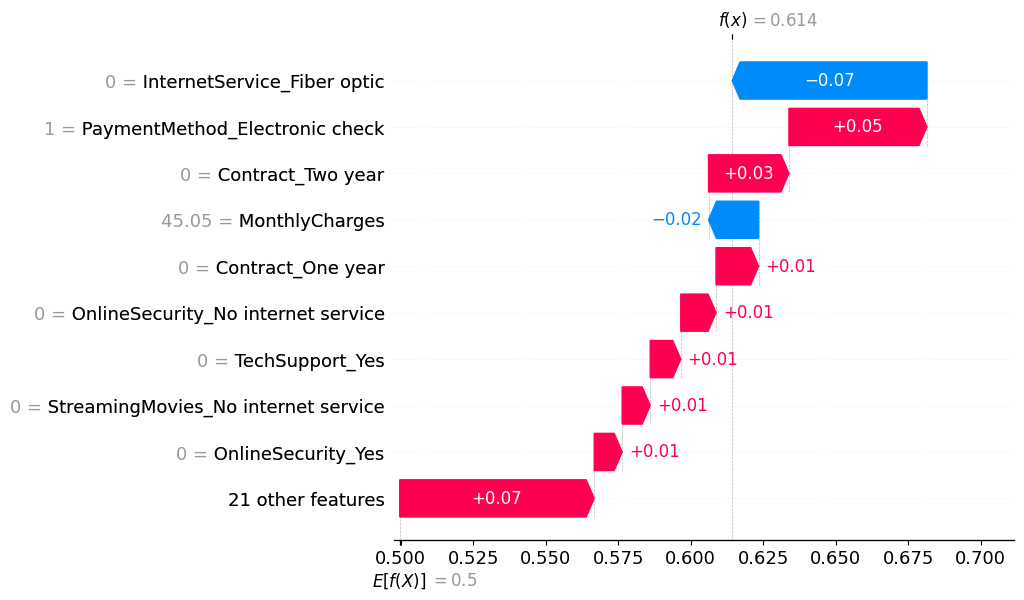

In [20]:
# Explain one actual churner — pick first customer from test set who actually churned
churn_indices = (y_test == 1).values.nonzero()[0]
customer_idx = churn_indices[0]

single_customer = X_test.iloc[[customer_idx]]
shap_single = explainer.shap_values(single_customer)

shap.waterfall_plot(shap.Explanation(
    values=shap_single[0][:, 1],
    base_values=explainer.expected_value[1],
    data=single_customer.iloc[0],
    feature_names=X_test.columns.tolist()
))

**Reading the waterfall plot:**
- Starts at `E[f(x)] = 0.5` — average churn probability across all customers
- Each red bar = a feature that pushed this customer's probability **up** toward churn
- Each blue bar = a feature that pushed the probability **down** away from churn
- Ends at `f(x)` — the model's final churn probability for this specific customer

This customer was flagged primarily because of `PaymentMethod_Electronic check` and no long-term contract — both strong churn signals in this dataset.

## Results Summary

| Model | Recall (threshold 0.5) | Recall (threshold 0.35) | Precision (0.35) |
|-------|----------------------|------------------------|-----------------|
| Logistic Regression (baseline) | 0.78 | 0.904 | 0.447 |
| Random Forest (default) | 0.47 | — | — |
| **Random Forest (tuned)** | **0.81** | **0.909** | **0.419** |

**Key insight — LR is nearly as good as RF:**  
After threshold tuning, LR reaches 0.904 recall vs RF at 0.909 — a difference of 0.5%. For a production system where interpretability matters (e.g. regulators asking "why was this customer flagged?"), LR might actually be the better choice. We chose RF as the final model because it captures feature interactions and generalizes better, but the gap is small on this dataset.

**Key drivers of churn:**
1. Short tenure — new customers haven't built loyalty yet
2. Month-to-month contract — no lock-in, easy to leave
3. Fiber optic internet — expensive plan, more competitive alternatives
4. Electronic check payment — associated with less committed customers
5. No online security or tech support — less invested in the service

**Business recommendation:**  
Target customers in the first 6 months with month-to-month contracts and fiber optic internet — they are the highest-risk group. Offer incentives to switch to annual contracts or add support services.